In [34]:
import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
colors = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59']  
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

palette = ['#cb17eb','#A4EB17', '#17EBC8', '#EB173A', '#ffde59', '#ccff33', '#ff36ab', '#e0fbfc', '#3772ff', '#45062e']  
sns.set_palette(palette)

# Sub Theme wise features

In [ ]:
demographic_cols__02_03 = [
    'HH_Size_FDQ',
    'Household_Type', 
    'Age',
    'Marital_Status',
]

income_stability_cols_03 = [
     'Max_Income_Activity',
    'Self_Employment_Source_Sector',
    'Regular_Wage_Source_Sector',
    'Casual_Labour_Source_Sector',
]

num_assets_cols_03_11 = [
    'Land_Ownership',
    'Possess_Television',
    'Possess_Laptop',
    'Possess_Mobile',
    'Possess_Bicycle',
    'Possess_Scooter',
    'Possess_Car',
    'Possess_Refrigerator',
    'Possess_WashingMachine',
    'Possess_AirCooler',
    'TV_Facility_Type',
]

income_cols_02_03_11 = [
    'Max_Income_Activity',
    'HH_Size_FDQ',
    'Total_consumption_value_rs'
]

device_access_cols_02_11 = [
    'Possess_Laptop',
    'Possess_Mobile',
    'Used_Internet_Last_30_Days',
]

online_activity_cols_04_07_15 = [
    'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
'ONLINE_EXPENDITURE'
]

professional_field_cols_02_03_04_07 = [ 
'Used_Internet_Last_30_Days'   ,
'Ration_Card_Type',
'Benefitted_From_PMGKY',
'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
]

warfare_usage_07 = [
'LPG_subsidy_received', 
'Free_electricity'
]

direct_indirect_warfare_usage_03_07 = [
'Ration_Card_Type',
'Benefitted_From_PMGKY',        
'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
]

# Level wise features

In [ ]:
l2 =  [
    'FSU_Serial_No',
'Relation_to_Head',
'Age',
'Marital_Status',
'Education_Level',
'Years_of_Education',
'Used_Internet_Last_30_Days',
]

l3 = [
    'HH_Size_FDQ',
        'FSU_Serial_No',
    'Max_Income_Activity',
'Self_Employment_Source_Sector',
'Regular_Wage_Source_Sector',
'Casual_Labour_Source_Sector',
'Household_Type',
'Land_Ownership',
'Type_of_Dwelling_Unit',
'Ration_Card_Type',
'Benefitted_From_PMGKY',
]

l4 = [
        'FSU_Serial_No',
'Ration_Rice',
'Ration_Wheat',
'Ration_Coarse_Grain',
'Ration_Sugar',
'Ration_Pulses',
'Ration_Edible_Oil',
'Ration_Other_Food_Items',
'Online_Groceries',
'Online_Milk',
'Online_Vegetables',
'Online_Fresh_Fruits',
'Online_Dry_Fruits',
'Online_Egg_Fish_Meat',
'Online_Served_Processed_Food',
'Online_Packed_Processed_Food',
'Online_Other_Food_Items',
]

l7 = [
        'FSU_Serial_No',
    'LPG_subsidy_received',
'LPG_subsidized_cylinders',
'Free_electricity',
'Total_textbooks',
'Free_school_bag_received',
'Ayushman_beneficiary',
'Medical_benefit_received',
'Online_purchase_fuel_light',
'Online_purchase_toilet_articles',
'Online_purchase_education',
'Online_purchase_medicine',
'Online_purchase_services',
]

l8 = [    'FSU_Serial_No',
'Total_consumption_value_rs']

l11 = [
       'FSU_Serial_No',
    'Possess_Television',
'Possess_Laptop',
'Possess_Mobile',
'Possess_Bicycle',
'Possess_Scooter',
'Possess_Car',
'Possess_Refrigerator',
'Possess_WashingMachine',
'Possess_AirCooler',
'TV_Facility_Type',
]

l15 = ['FSU_Serial_No', 'ONLINE_EXPENDITURE']

# Functions

In [ ]:
def merge_plot_heatmap(levels: list, cols: list, title: str) -> None:
    # Empty list to store the dataframes
    dfs = []
    
    # Load the data
    for df in levels:
        if df == 2:
            df2 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-2.parquet")
            dfs.append(df2)
        elif df == 3:
            df3 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-3.parquet")
            dfs.append(df3)
        elif df == 4:
            df4 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-4.parquet")
            dfs.append(df4)
        elif df == 7:
            df7 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-7.parquet")
            dfs.append(df7)
        elif df == 8:
            df8 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-8.parquet")
            dfs.append(df8)
        elif df == 11:
            df11 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-11.parquet")
            dfs.append(df11)
        elif df == 15:
            df15 = pl.read_parquet(r"C:\Users\Rudra\Desktop\rural-financial-inclusion-govt-scheme-recommendation\notebooks\correlations-all-levels\corr\cor-15.parquet")
            dfs.append(df15)

    # Check if we have loaded more than 1 dataframe
    if len(dfs) > 1:
        # Start with the first dataframe
        mdf = dfs[0]
        # Join the rest of the dataframes
        for df in dfs[1:]:
            mdf = mdf.join(df, on="FSU_Serial_No", how="inner")  # Adjust join type if needed
    
    # Filter the columns based on input list
    mdf = mdf.select(cols)
    
    # Compute the correlation matrix
    corr = mdf.corr()

    # Mask for the upper triangle 
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True,
        cmap='viridis',
        center=0,
        cbar=True,
        mask=mask,
        xticklabels=mdf.columns,
        yticklabels=mdf.columns
    )

    plt.title(f"{title} Correlation Matrix Heatmap")
    plt.tight_layout()
    plt.show()

    # Clear memory 
    del mdf
    for df in dfs:
        del df


# Demographic

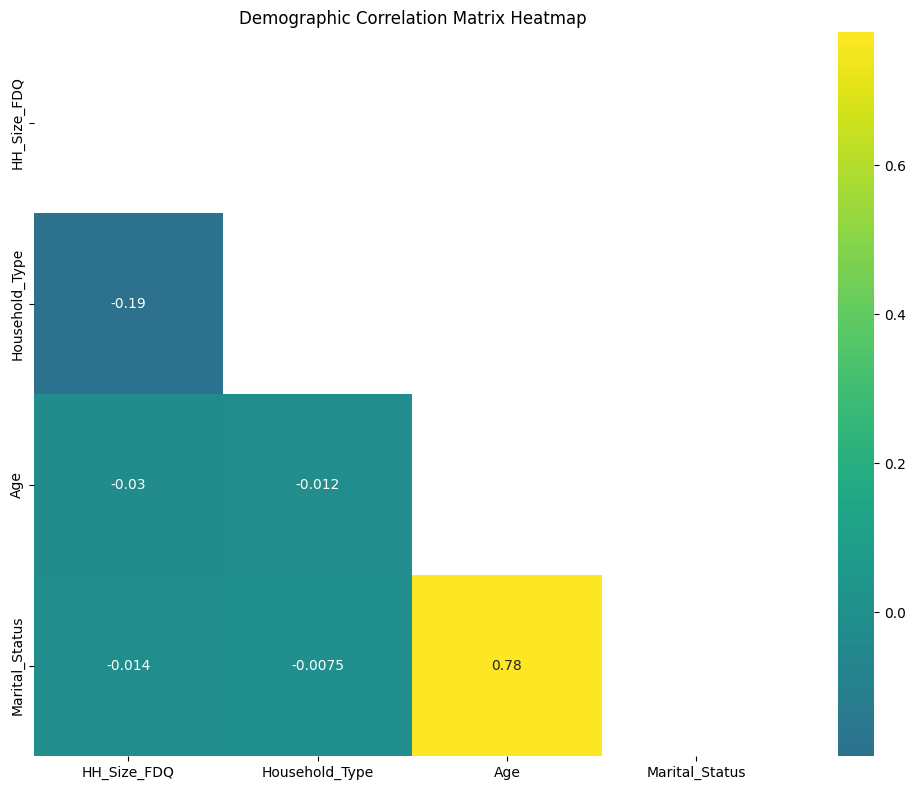

In [39]:
merge_plot_heatmap(
    levels=[2, 3],
    cols=demographic_cols__02_03,
    title="Demographic"
)

In [40]:
merge_plot_heatmap(
    levels=[3],
    cols=income_stability_cols_03,
    title="Income Stability"
)

UnboundLocalError: cannot access local variable 'mdf' where it is not associated with a value

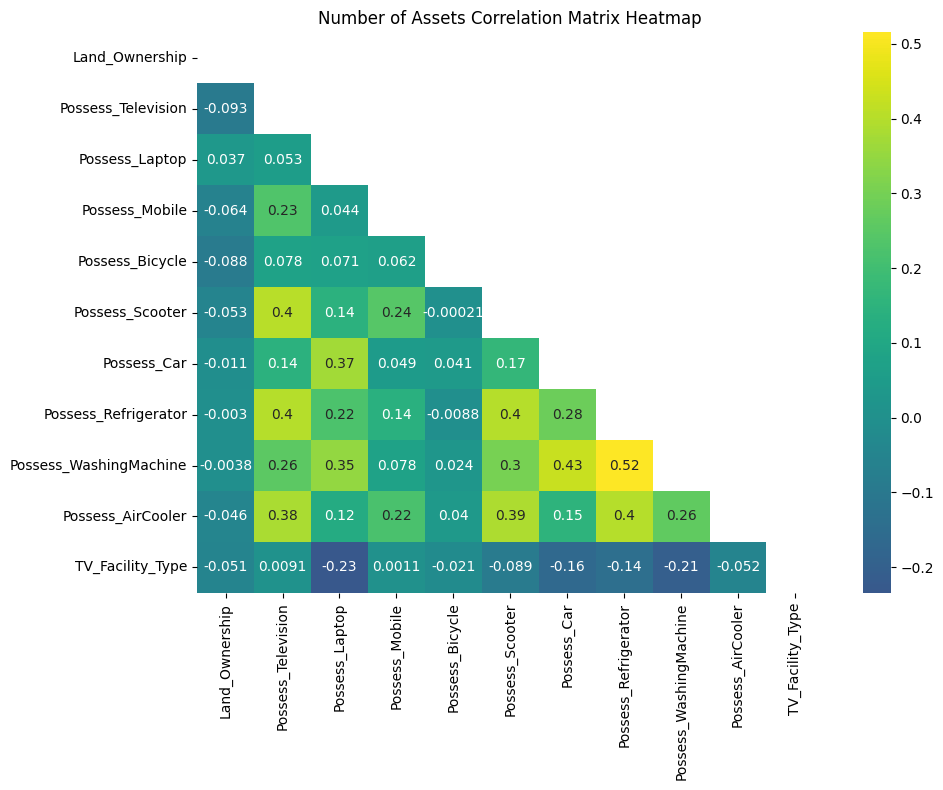

In [41]:
merge_plot_heatmap(
    levels=[3, 11],
    cols=num_assets_cols_03_11,
    title="Number of Assets"
)

In [42]:
merge_plot_heatmap(
    levels=[2, 3, 11],
    cols=income_cols_02_03_11,
    title="Income"
)

ColumnNotFoundError: Total_consumption_value_rs

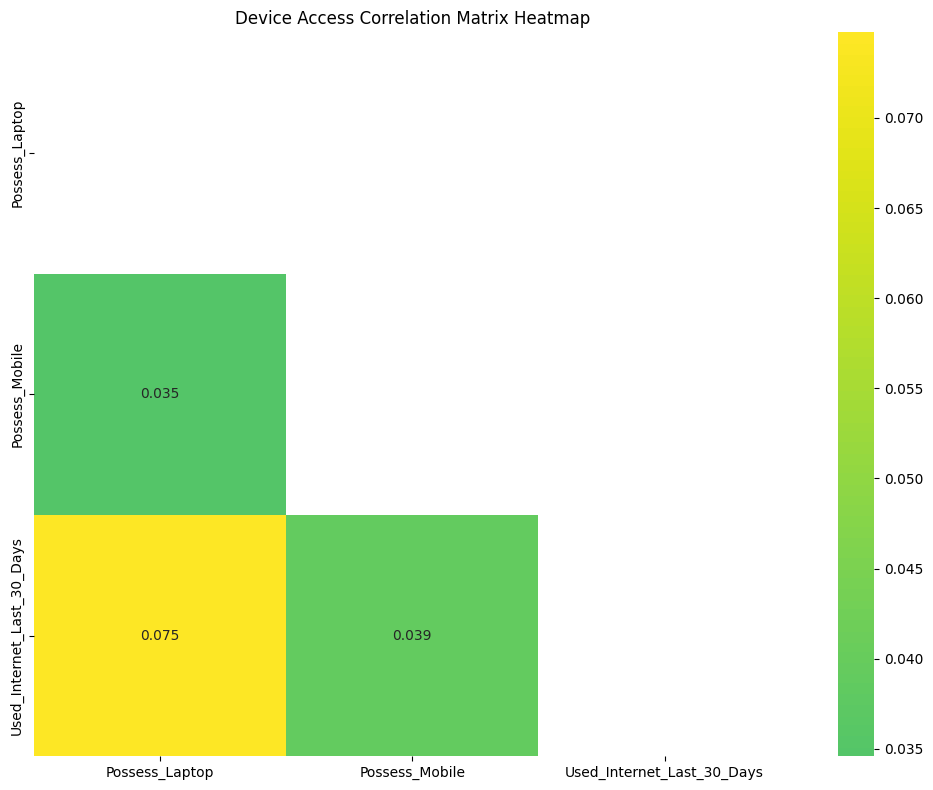

In [43]:
merge_plot_heatmap(
    levels=[2, 11],
    cols=device_access_cols_02_11,
    title="Device Access"
)

In [ ]:
l

In [49]:
merge_plot_heatmap(
    levels=[4, 7, 15],
    cols=online_activity_cols_04_07,
    title="Online Activity"
)

MemoryError: Unable to allocate 9.71 GiB for an array with shape (15, 86868432) and data type float64

In [45]:
merge_plot_heatmap(
    levels=[2, 3],
    cols=professional_field_cols_02_03_04_07,
    title="Professional Field"
)

ColumnNotFoundError: Ration_Rice

In [46]:
merge_plot_heatmap(
    levels=[7],
    cols=warfare_usage_07,
    title="Walfare"
)

UnboundLocalError: cannot access local variable 'mdf' where it is not associated with a value

In [51]:
merge_plot_heatmap(
    levels=[2, 3],
    cols=direct_indirect_warfare_usage_03_07,
    title="Direct & Indirect Warfare"
)

ColumnNotFoundError: LPG_subsidy_received